In [1]:
# Copy file tu GCS ve moi truong
!gsutil cp gs://dbm-dat-dataset/SER_final_dataset.zip /kaggle/working/

Copying gs://dbm-dat-dataset/SER_final_dataset.zip...
==> NOTE: You are downloading one or more large file(s), which would
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compiled crcmod be
installed (see "gsutil help crcmod").


Operation completed over 1 objects/863.7 MiB.                                    


In [2]:
!unzip -qq /kaggle/working/SER_final_dataset.zip -d /kaggle/working/SER_final_dataset

In [3]:
import wandb
wandb.login(key="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")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: minhtrietsonny (minhtrietsonny-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
import pandas as pd
import os
import glob
from sklearn.model_selection import train_test_split

csv_files = glob.glob('/kaggle/working/SER_final_dataset/output/train.csv', recursive=True)
if csv_files:
    metadata_path = csv_files[0]
    print(f"Found metadata file: {metadata_path}")
else:
    metadata_path = '/kaggle/working/SER_final_dataset/output/train.csv'
    print(f"Assume metadata path: {metadata_path}")

Found metadata file: /kaggle/working/SER_final_dataset/output/train.csv


In [5]:
def load_dataset_from_dir(metadata_path):
    df = pd.read_csv(metadata_path)
    return df.reset_index(drop=True)

df = load_dataset_from_dir(metadata_path)

train_df = df
val_df = pd.read_csv("/kaggle/working/SER_final_dataset/output/val.csv")
test_df = pd.read_csv("/kaggle/working/SER_final_dataset/output/test.csv")

print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 10304
Val size: 975
Test size: 976


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
import os
import pandas as pd
import librosa
import numpy as np
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from tqdm.auto import tqdm
import wandb
from sklearn.metrics import accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [7]:
import torch
import torch.nn as nn
from transformers import Wav2Vec2Model, Wav2Vec2Processor

class SER_Wav2Vec2_BiLSTM_Attn(nn.Module):
    def __init__(self, num_classes=7, frozen=True):
        super().__init__()
        self.wav2vec2 = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")

        if frozen:
            for param in self.wav2vec2.parameters():
                param.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=768,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.attention = nn.Sequential(
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        with torch.no_grad():
            features = self.wav2vec2(x).last_hidden_state

        lstm_out, _ = self.lstm(features)

        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)

        logits = self.classifier(context)
        return logits

In [8]:
import torch
import torch.nn as nn
from transformers import Wav2Vec2Model, Wav2Vec2Processor

class SER_Wav2Vec2_Transformer(nn.Module):
    def __init__(self, num_classes=7, frozen=True, nhead=8, num_layers=2):
        super().__init__()
        self.wav2vec2 = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")

        if frozen:
            for param in self.wav2vec2.parameters():
                param.requires_grad = False

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=768,
            nhead=nhead,
            dim_feedforward=1024,
            dropout=0.1,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        outputs = self.wav2vec2(x).last_hidden_state
        trans_out = self.transformer_encoder(outputs)
        context = torch.mean(trans_out, dim=1)
        logits = self.classifier(context)
        return logits

In [9]:
# Chon model o day
model = SER_Wav2Vec2_BiLSTM_Attn(num_classes=7).to(device)
# model = SER_Wav2Vec2_Transformer(num_classes=7).to(device)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
class SERDataset(Dataset):
    def __init__(self, df, directory, processor, max_duration=5.0):
        self.df = df
        self.directory = directory
        self.processor = processor
        self.max_samples = int(max_duration * 16000)

        self.label_map = {
            'neutral': 0, 'happy': 1, 'surprise': 2,
            'angry': 3, 'sad': 4, 'fear': 5, 'disgust': 6
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        raw_path = row['file_name'] if 'file_name' in self.df.columns else row['filepath']
        file_name_only = os.path.basename(raw_path)
        file_path = os.path.join(self.directory, file_name_only)

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Loi: Khong tim thay file {file_path}. Hay kiem tra lai thu muc unzip.")

        speech, _ = librosa.load(file_path, sr=16000)

        if len(speech) > self.max_samples:
            speech = speech[:self.max_samples]
        else:
            speech = np.pad(speech, (0, self.max_samples - len(speech)))

        inputs = self.processor(speech, sampling_rate=16000, return_tensors="pt").input_values
        label = self.label_map.get(str(row['emotion']).lower(), 0)

        return inputs.squeeze(0), torch.tensor(label, dtype=torch.long)

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")

train_dataset = SERDataset(train_df, "/kaggle/working/SER_final_dataset/output/train_data", processor)
val_dataset = SERDataset(val_df, "/kaggle/working/SER_final_dataset/output/val_data", processor)
test_dataset = SERDataset(test_df, "/kaggle/working/SER_final_dataset/output/test_data", processor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

In [11]:
from tqdm.auto import tqdm

def train_model(model, train_loader, val_loader, config):
    run = wandb.init(project="SER-Wav2Vec2", config=config)

    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'])
    criterion = nn.CrossEntropyLoss()

    best_loss = float('inf')

    # Luu history de ve bieu do sau
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    print(f"\nBat dau huan luyen: {config['epochs']} epochs")
    print(f"Model se duoc luu tai: WavVecBest.pt\n")

    for epoch in range(config['epochs']):
        # --- TRAINING ---
        model.train()
        train_loss, train_acc = 0, 0

        train_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{config['epochs']}] TRAIN", unit="batch")

        for x, y in train_bar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            acc = (outputs.argmax(1) == y).float().mean().item()
            train_acc += acc

            train_bar.set_postfix(loss=loss.item(), acc=acc)

        # --- VALIDATION ---
        model.eval()
        val_loss, val_acc = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                v_loss = criterion(outputs, y).item()
                val_loss += v_loss
                val_acc += (outputs.argmax(1) == y).float().mean().item()

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = train_acc / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = val_acc / len(val_loader)

        # Luu vao history
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)

        print(f"Ket qua Epoch {epoch+1}:")
        print(f"   [Train] Loss: {avg_train_loss:.4f} | [Train] Acc: {avg_train_acc:.4f} | [Val] Loss: {avg_val_loss:.4f} | [Val] Acc: {avg_val_acc:.4f}")

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(model.state_dict(), "WavVecBest.pt")
            print(f"   [SAVED] Da luu model moi (Loss cai thien: {best_loss:.4f}) -> WavVecBest.pt")

        wandb.log({
            "epoch": epoch + 1,
            "train/loss": avg_train_loss,
            "train/acc": avg_train_acc,
            "val/loss": avg_val_loss,
            "val/acc": avg_val_acc,
            "best_loss": best_loss
        })
        print("-" * 50)

    print("\nHuan luyen hoan tat!")
    run.finish()
    return history

config = {
    "lr": 1e-4,
    "epochs": 30,
    "batch_size": 16,
    "model": "Wav2Vec2+Transformer"
}

In [12]:
history = train_model(model, train_loader, val_loader, config)

wandb: setting up run nnp4dm3o
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260313_170721-nnp4dm3o
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run neat-violet-46
wandb: ⭐️ View project at https://wandb.ai/minhtrietsonny-fpt-university/SER-Wav2Vec2
wandb: 🚀 View run at https://wandb.ai/minhtrietsonny-fpt-university/SER-Wav2Vec2/runs/nnp4dm3o



Bat dau huan luyen: 30 epochs
Model se duoc luu tai: WavVecBest.pt



Epoch [1/30] TRAIN:   0%|          | 0/644 [00:00<?, ?batch/s]

Ket qua Epoch 1:
   [Train] Loss: 1.4750 | [Train] Acc: 0.4043 | [Val] Loss: 1.8611 | [Val] Acc: 0.3443
   [SAVED] Da luu model moi (Loss cai thien: 1.8611) -> WavVecBest.pt
--------------------------------------------------


Epoch [2/30] TRAIN:   0%|          | 0/644 [00:00<?, ?batch/s]

...

Ket qua Epoch 29:
   [Train] Loss: 0.1002 | [Train] Acc: 0.9660 | [Val] Loss: 1.5230 | [Val] Acc: 0.6642
--------------------------------------------------


Epoch [30/30] TRAIN:   0%|          | 0/644 [00:00<?, ?batch/s]

wandb: updating run metadata


Ket qua Epoch 30:
   [Train] Loss: 0.0913 | [Train] Acc: 0.9688 | [Val] Loss: 1.5176 | [Val] Acc: 0.6645
--------------------------------------------------

Huan luyen hoan tat!


wandb: uploading data
wandb: 
wandb: Run history:
wandb:  best_loss █▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:      epoch ▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
wandb:  train/acc ▁▄▅▅▆▆▆▇▇▇▇▇▇▇▇▇██████████████
wandb: train/loss █▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:    val/acc ▁▃▃▄▃▅▇▅▇▇█▆▇█▆▇██▇▅▇▆▇▇▇█▇███
wandb:   val/loss ▆▃▅▄▇▄▂▄▂▂▁▄▂▂▅▂▂▂▂█▃▅▄▅▃▃▄▄▃▃
wandb: 
wandb: Run summary:
wandb:  best_loss 1.23689
wandb:      epoch 30
wandb:  train/acc 0.96885
wandb: train/loss 0.09126
wandb:    val/acc 0.66448
wandb:   val/loss 1.51756
wandb: 
wandb: 🚀 View run neat-violet-46 at: https://wandb.ai/minhtrietsonny-fpt-university/SER-Wav2Vec2/runs/nnp4dm3o
wandb: ⭐️ View project at: https://wandb.ai/minhtrietsonny-fpt-university/SER-Wav2Vec2
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260313_170721-nnp4dm3o/logs


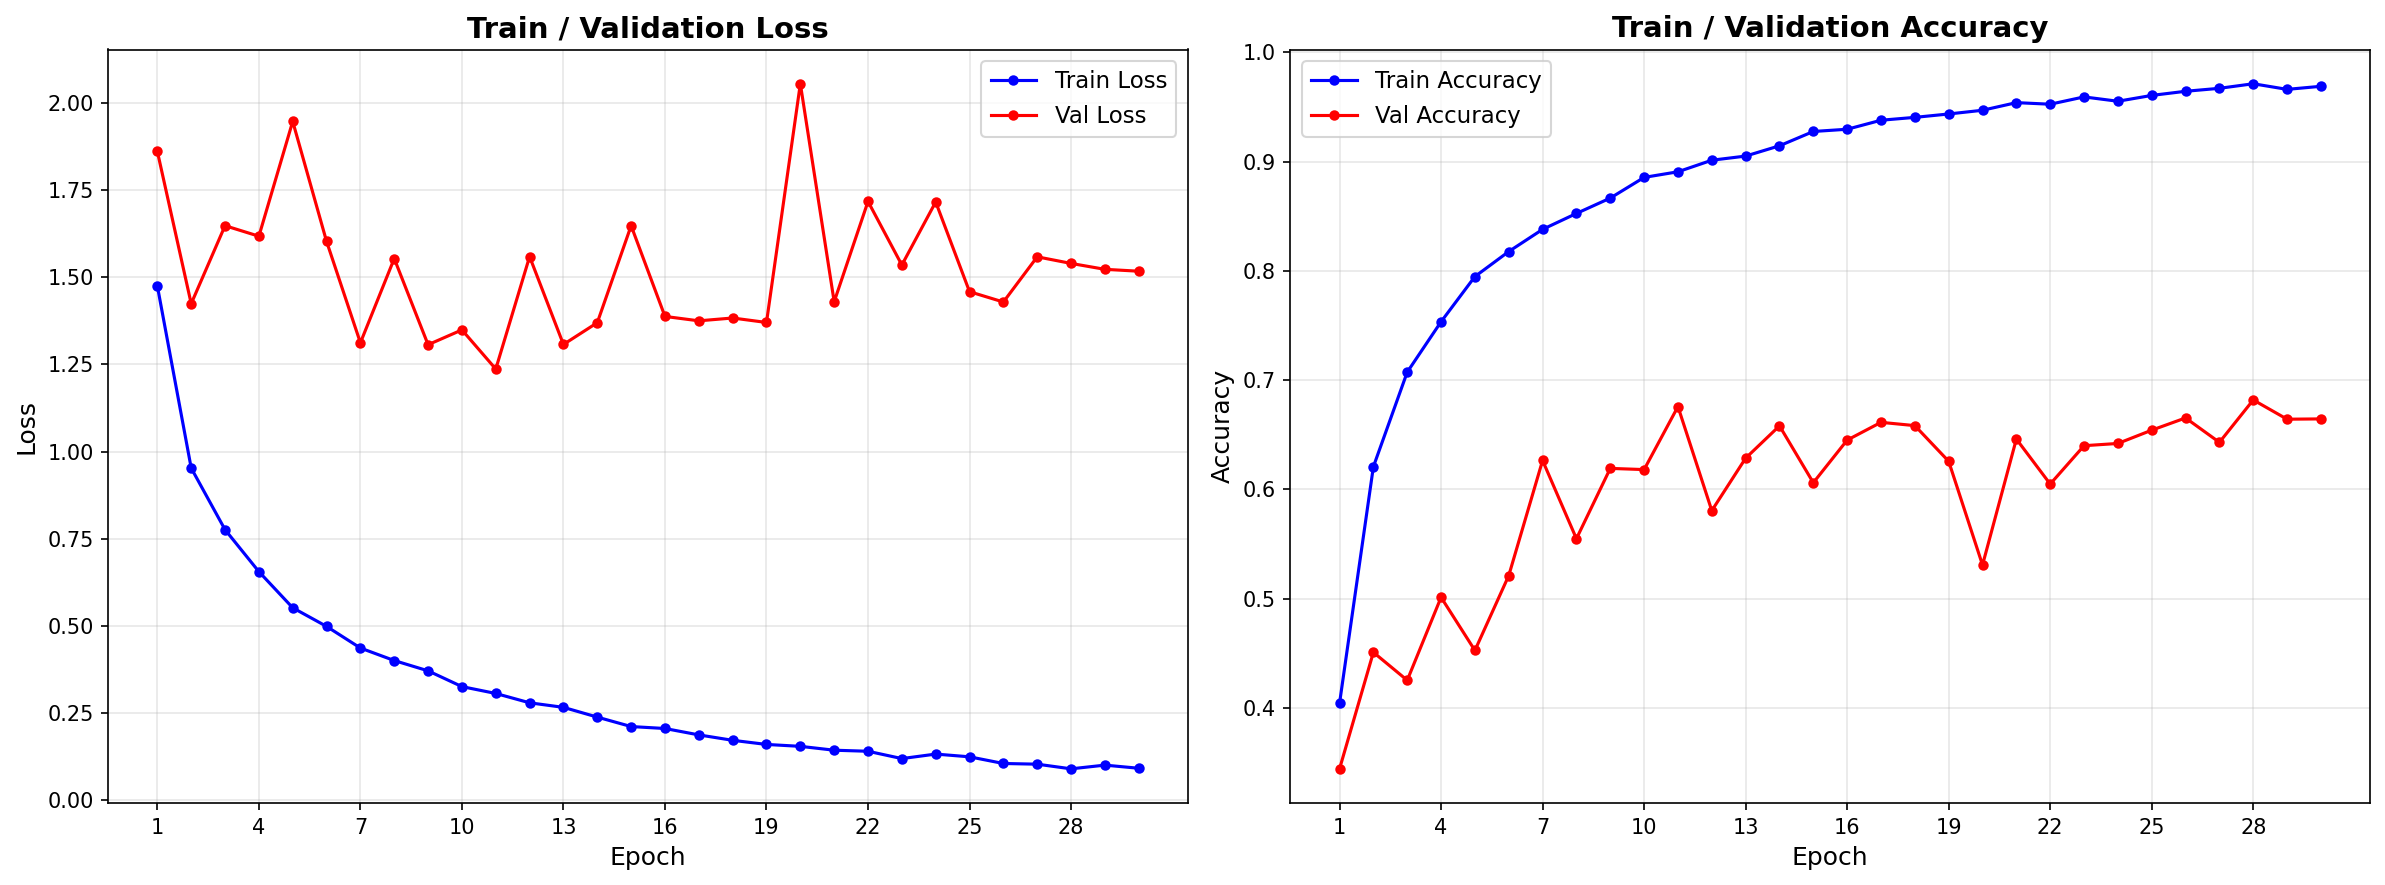

Da luu bieu do: train_val_curves.png


In [13]:
# ==========================================
# VE BIEU DO TRAIN/VAL LOSS VA ACCURACY
# ==========================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Loss ---
axes[0].plot(epochs_range, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'], 'r-o', markersize=4, label='Val Loss')
axes[0].set_title('Train / Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(epochs_range)[::max(1, len(history['train_loss']) // 10)])

# --- Accuracy ---
axes[1].plot(epochs_range, history['train_acc'], 'b-o', markersize=4, label='Train Accuracy')
axes[1].plot(epochs_range, history['val_acc'], 'r-o', markersize=4, label='Val Accuracy')
axes[1].set_title('Train / Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(epochs_range)[::max(1, len(history['train_acc']) // 10)])

plt.tight_layout()
plt.savefig('train_val_curves.png', bbox_inches='tight', dpi=200)
plt.show()
print("Da luu bieu do: train_val_curves.png")

In [14]:
# ==========================================
# TEST SET INFERENCE
# ==========================================
import os
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import Wav2Vec2Processor
from sklearn.metrics import classification_report, accuracy_score
from IPython.display import display

csv_path = "/kaggle/working/SER_final_dataset/output/test.csv"
audio_dir = "/kaggle/working/SER_final_dataset/output/test_data"
model_path = "/kaggle/working/WavVecBest.pt"

print(f"Bat dau quy trinh test voi tap du lieu tuy chinh.")
print(f"CSV: {csv_path}")
print(f"Dir: {audio_dir}")

test_df_custom = pd.read_csv(csv_path)

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")

test_dataset_custom = SERDataset(test_df_custom, audio_dir, processor)
test_loader_custom = DataLoader(test_dataset_custom, batch_size=16, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Phai dung cung kien truc voi model da train
model_test = SER_Wav2Vec2_BiLSTM_Attn(num_classes=7).to(device)
# model_test = SER_Wav2Vec2_Transformer(num_classes=7).to(device)

try:
    model_test.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    print(f"[OK] Da load weights thanh cong tu {model_path}")
except Exception as e:
    print(f"[LOI] Loi khi load model: {e}")

model_test.eval()

# ==========================================
# INFERENCE - Thu thap predictions va probabilities
# ==========================================
all_preds = []
all_labels = []
all_probs = []
criterion = torch.nn.CrossEntropyLoss()
test_loss = 0

print(f"Bat dau danh gia model tren {len(test_dataset_custom)} mau test...")
test_bar = tqdm(test_loader_custom, desc="Testing (Custom Data)", unit="batch")

with torch.no_grad():
    for x, y in test_bar:
        x, y = x.to(device), y.to(device)
        outputs = model_test(x)

        loss = criterion(outputs, y)
        test_loss += loss.item()

        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# ==========================================
# IN KET QUA CO BAN
# ==========================================
avg_test_loss = test_loss / len(test_loader_custom)
test_acc = accuracy_score(all_labels, all_preds)

print(f"\nKet qua Test Set:")
print(f"   Test Loss: {avg_test_loss:.4f} | Test Accuracy: {test_acc:.4f}\n")

core_label_map = {
    'neutral': 0, 'happy': 1, 'surprise': 2,
    'angry': 3, 'sad': 4, 'fear': 5, 'disgust': 6
}

display_names = {
    'neutral': 'Neutral', 'happy': 'Happy', 'surprise': 'Surprise',
    'angry': 'Angry', 'sad': 'Sad', 'fear': 'Fear', 'disgust': 'Disgust'
}

idx_to_label = {v: k for k, v in core_label_map.items()}

csv_emotions_text = set(test_df_custom['emotion'].astype(str).str.lower())
unique_labels = sorted([core_label_map[emo] for emo in csv_emotions_text if emo in core_label_map])
present_label_names_raw = [idx_to_label[idx] for idx in unique_labels]
present_label_names = [display_names[name] for name in present_label_names_raw]
num_classes = len(unique_labels)

report_dict = classification_report(all_labels, all_preds,
                                    labels=unique_labels,
                                    target_names=present_label_names,
                                    zero_division=0, output_dict=True)

metrics_data = []
for label in present_label_names:
    metrics_data.append({
        'Emotion': label,
        'Precision': round(report_dict[label]['precision'] * 100),
        'Recall': round(report_dict[label]['recall'] * 100),
        'F1-score': round(report_dict[label]['f1-score'] * 100),
        'Support': int(report_dict[label]['support'])
    })

df_metrics = pd.DataFrame(metrics_data)
df_metrics.set_index('Emotion', inplace=True)

styled_df = df_metrics.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#658bc2'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'left')]},
    {'selector': 'th.row_heading', 'props': [('background-color', '#658bc2'), ('color', 'white')]},
    {'selector': 'td', 'props': [('text-align', 'right'), ('padding', '10px')]}
]).set_properties(**{'background-color': '#ffffff', 'border': '1px solid #eeeeee'})

display(styled_df)

Bat dau quy trinh test voi tap du lieu tuy chinh.
CSV: /kaggle/working/SER_final_dataset/output/test.csv
Dir: /kaggle/working/SER_final_dataset/output/test_data


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[OK] Da load weights thanh cong tu /kaggle/working/WavVecBest.pt
Bat dau danh gia model tren 976 mau test...


Testing (Custom Data):   0%|          | 0/61 [00:00<?, ?batch/s]


Ket qua Test Set:
   Test Loss: 1.4978 | Test Accuracy: 0.6178



,Precision,Recall,F1-score,Support
Emotion,,,,
Neutral,57,77,66,142
Happy,47,53,49,139
Surprise,73,73,73,139
Angry,64,81,71,139
Sad,41,24,30,139
Fear,72,68,70,139
Disgust,78,57,66,139


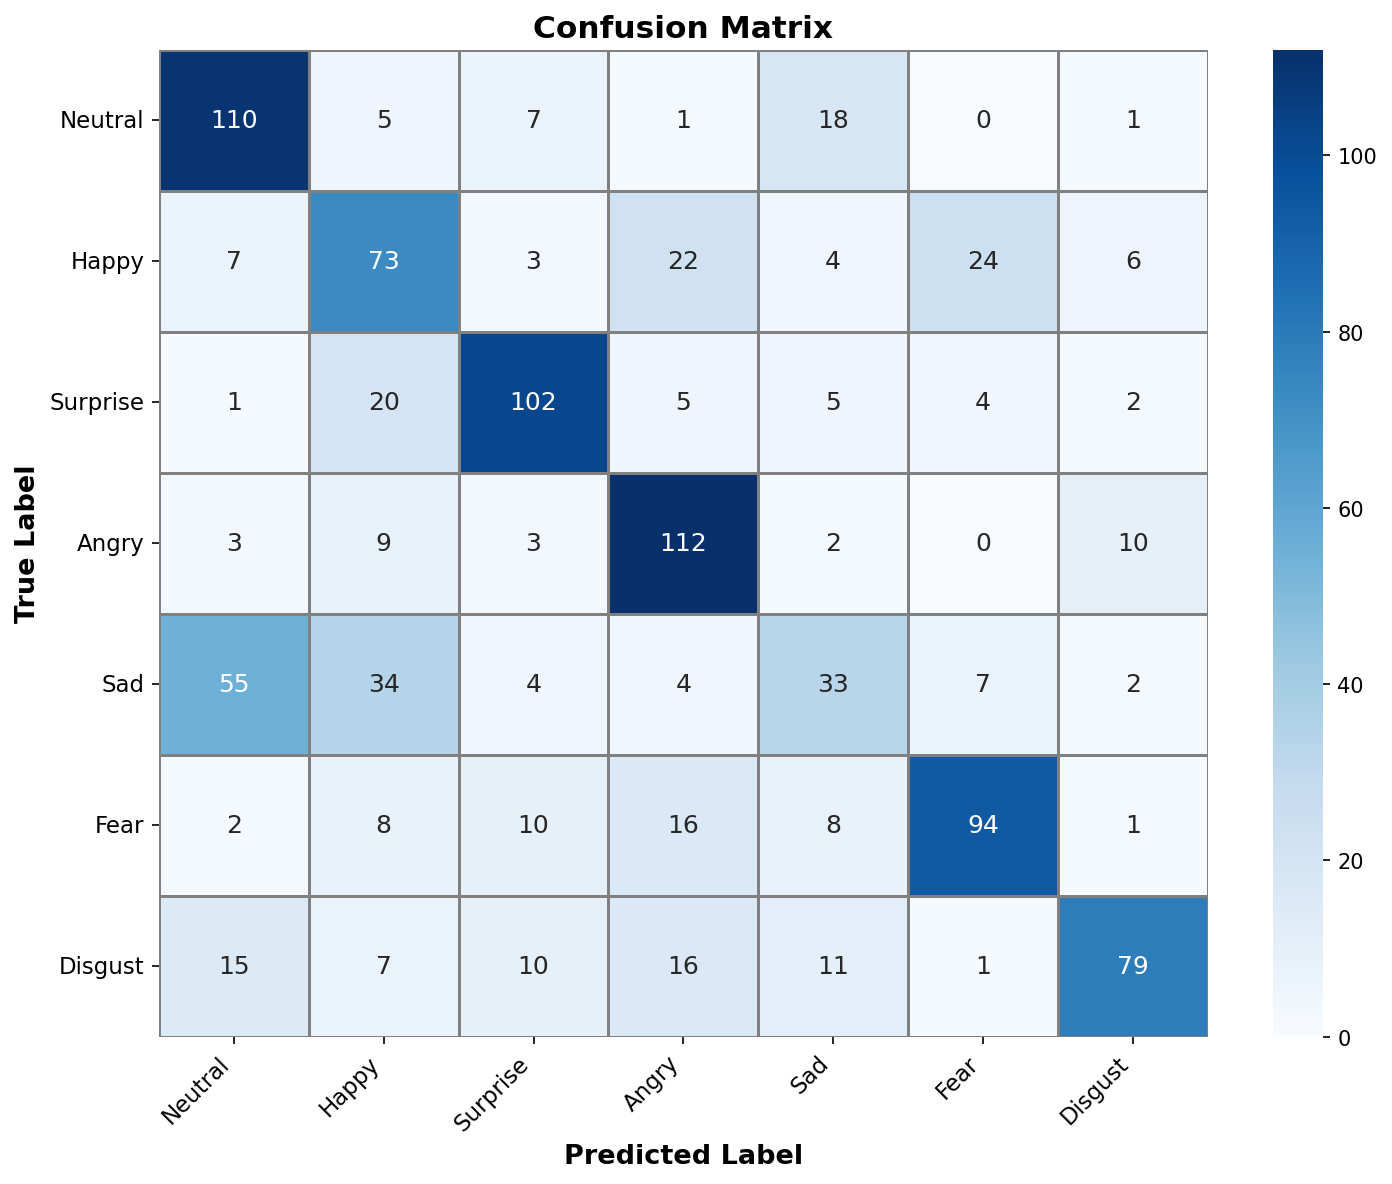

Da luu: confusion_matrix.png


In [15]:
# ==========================================
# CONFUSION MATRIX (RAW COUNTS)
# ==========================================
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import label_binarize
from itertools import cycle

matplotlib.rcParams['figure.dpi'] = 150

cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_label_names,
            yticklabels=present_label_names,
            ax=ax, linewidths=0.5, linecolor='gray',
            annot_kws={"size": 12})
ax.set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label', fontsize=13, fontweight='bold')
ax.set_title('Confusion Matrix', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=200)
plt.show()
print("Da luu: confusion_matrix.png")

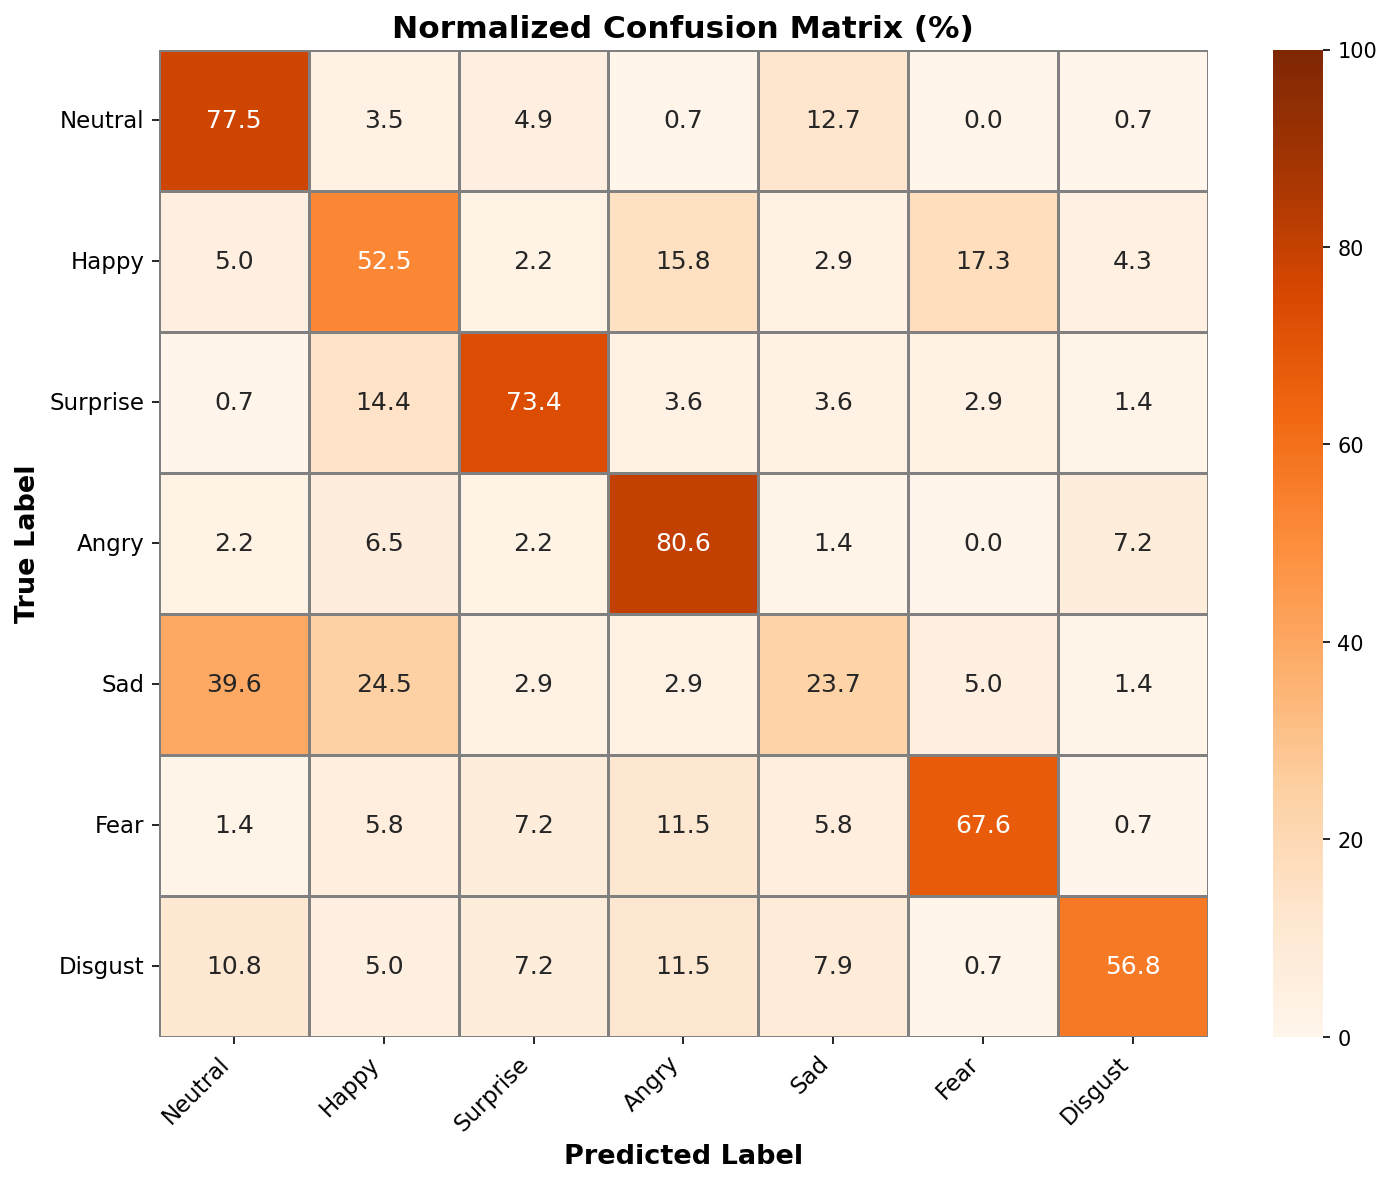

Da luu: confusion_matrix_normalized.png


In [16]:
# ==========================================
# NORMALIZED CONFUSION MATRIX (%)
# ==========================================
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Oranges',
            xticklabels=present_label_names,
            yticklabels=present_label_names,
            ax=ax, linewidths=0.5, linecolor='gray',
            annot_kws={"size": 12},
            vmin=0, vmax=100)
ax.set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label', fontsize=13, fontweight='bold')
ax.set_title('Normalized Confusion Matrix (%)', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix_normalized.png', bbox_inches='tight', dpi=200)
plt.show()
print("Da luu: confusion_matrix_normalized.png")

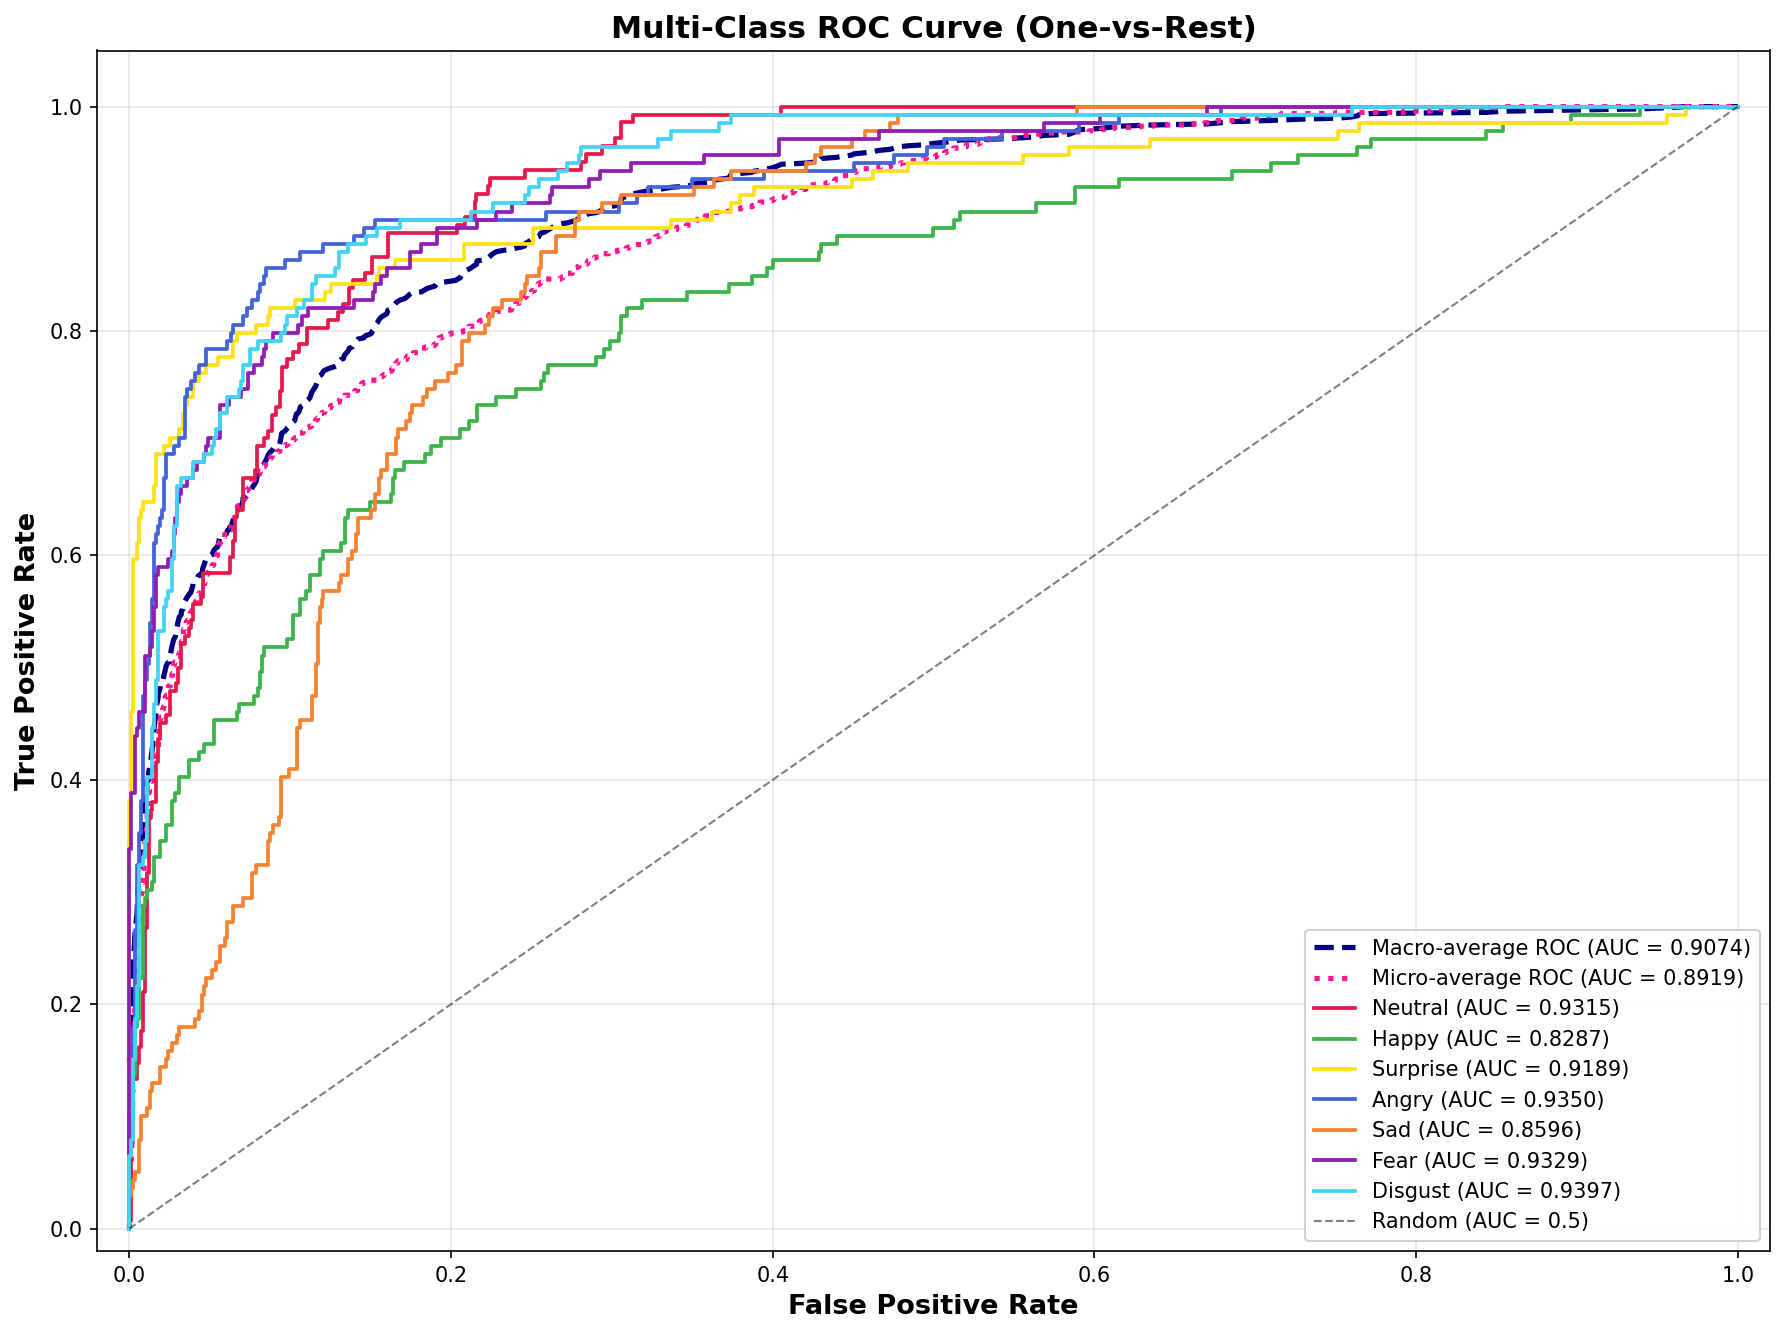

Da luu: roc_curve_multiclass.png

       AUC SCORES (One-vs-Rest)
        Neutral: 0.9315
          Happy: 0.8287
       Surprise: 0.9189
          Angry: 0.9350
            Sad: 0.8596
           Fear: 0.9329
        Disgust: 0.9397
--------------------------------------------------
      Macro-avg: 0.9074
      Micro-avg: 0.8919


In [17]:
# ==========================================
# ROC CURVE & AUC (PER-CLASS + MACRO/MICRO)
# ==========================================

# Binarize labels cho multi-class ROC
all_labels_bin = label_binarize(all_labels, classes=unique_labels)

# Truong hop chi co 2 class
if num_classes == 2:
    all_labels_bin = np.hstack([1 - all_labels_bin, all_labels_bin])

# Lay chi cac cot probability tuong ung voi unique_labels
all_probs_filtered = all_probs[:, unique_labels]

# Tinh ROC cho tung class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs_filtered[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(all_labels_bin.ravel(), all_probs_filtered.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# --- VE BIEU DO ROC TOAN BO ---
fig, ax = plt.subplots(figsize=(12, 9))

# Macro & Micro
ax.plot(fpr["macro"], tpr["macro"],
        label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.4f})',
        color='navy', linestyle='--', linewidth=2.5)

ax.plot(fpr["micro"], tpr["micro"],
        label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.4f})',
        color='deeppink', linestyle=':', linewidth=2.5)

# Per-class
colors = cycle(['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#42d4f4',
                '#f032e6', '#bfef45', '#fabed4'])

for i, color in zip(range(num_classes), colors):
    class_name = present_label_names[i]
    ax.plot(fpr[i], tpr[i], color=color, linewidth=1.8,
            label=f'{class_name} (AUC = {roc_auc[i]:.4f})')

# Duong cheo (random)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.5)')

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
ax.set_title('Multi-Class ROC Curve (One-vs-Rest)', fontsize=15, fontweight='bold')
ax.legend(loc="lower right", fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve_multiclass.png', bbox_inches='tight', dpi=200)
plt.show()
print("Da luu: roc_curve_multiclass.png")

# --- IN BANG AUC ---
print("\n" + "=" * 50)
print("       AUC SCORES (One-vs-Rest)")
print("=" * 50)
for i in range(num_classes):
    print(f"   {present_label_names[i]:>12s}: {roc_auc[i]:.4f}")
print("-" * 50)
print(f"   {'Macro-avg':>12s}: {roc_auc['macro']:.4f}")
print(f"   {'Micro-avg':>12s}: {roc_auc['micro']:.4f}")
print("=" * 50)

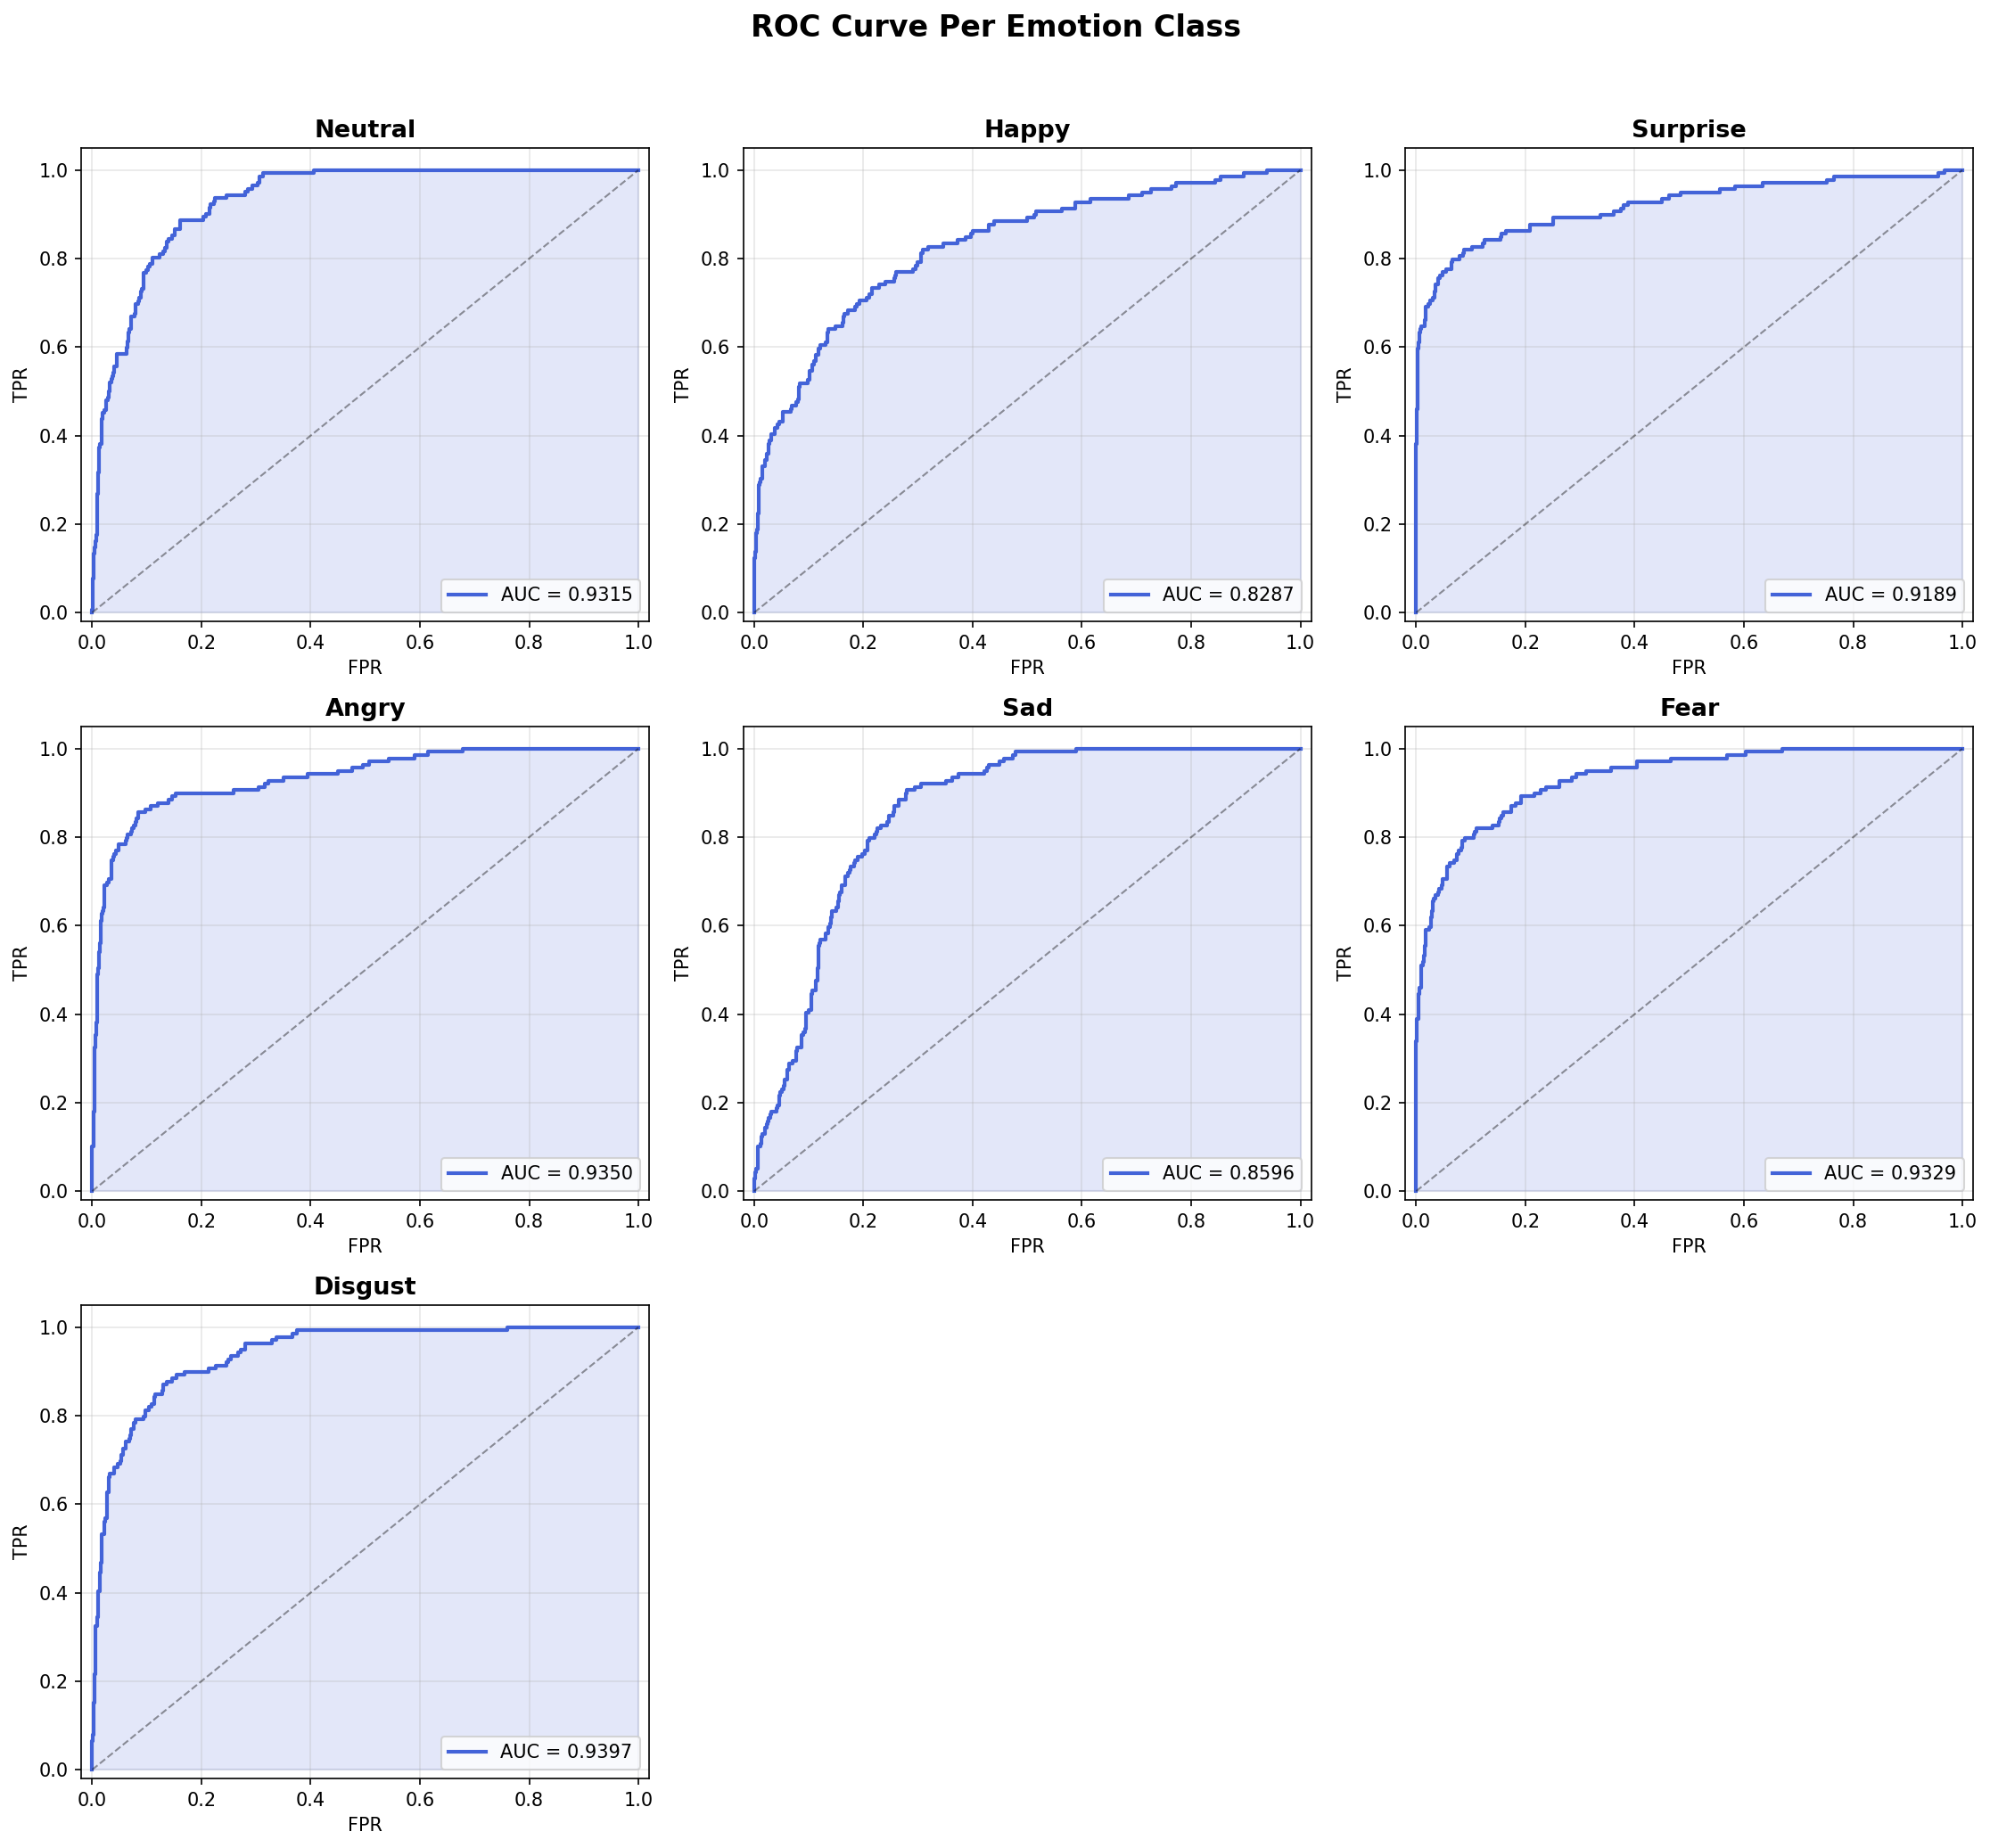

Da luu: roc_curve_per_class.png


In [18]:
# ==========================================
# ROC CURVE RIENG TUNG CLASS (SUBPLOT GRID)
# ==========================================
n_cols = 3
n_rows = (num_classes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = axes.flatten()

for i in range(num_classes):
    ax = axes[i]
    ax.plot(fpr[i], tpr[i], color='#4363d8', linewidth=2,
            label=f'AUC = {roc_auc[i]:.4f}')
    ax.fill_between(fpr[i], tpr[i], alpha=0.15, color='#4363d8')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.05])
    ax.set_title(f'{present_label_names[i]}', fontsize=13, fontweight='bold')
    ax.set_xlabel('FPR', fontsize=10)
    ax.set_ylabel('TPR', fontsize=10)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)

# An cac subplot thua
for j in range(num_classes, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ROC Curve Per Emotion Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('roc_curve_per_class.png', bbox_inches='tight', dpi=200)
plt.show()
print("Da luu: roc_curve_per_class.png")

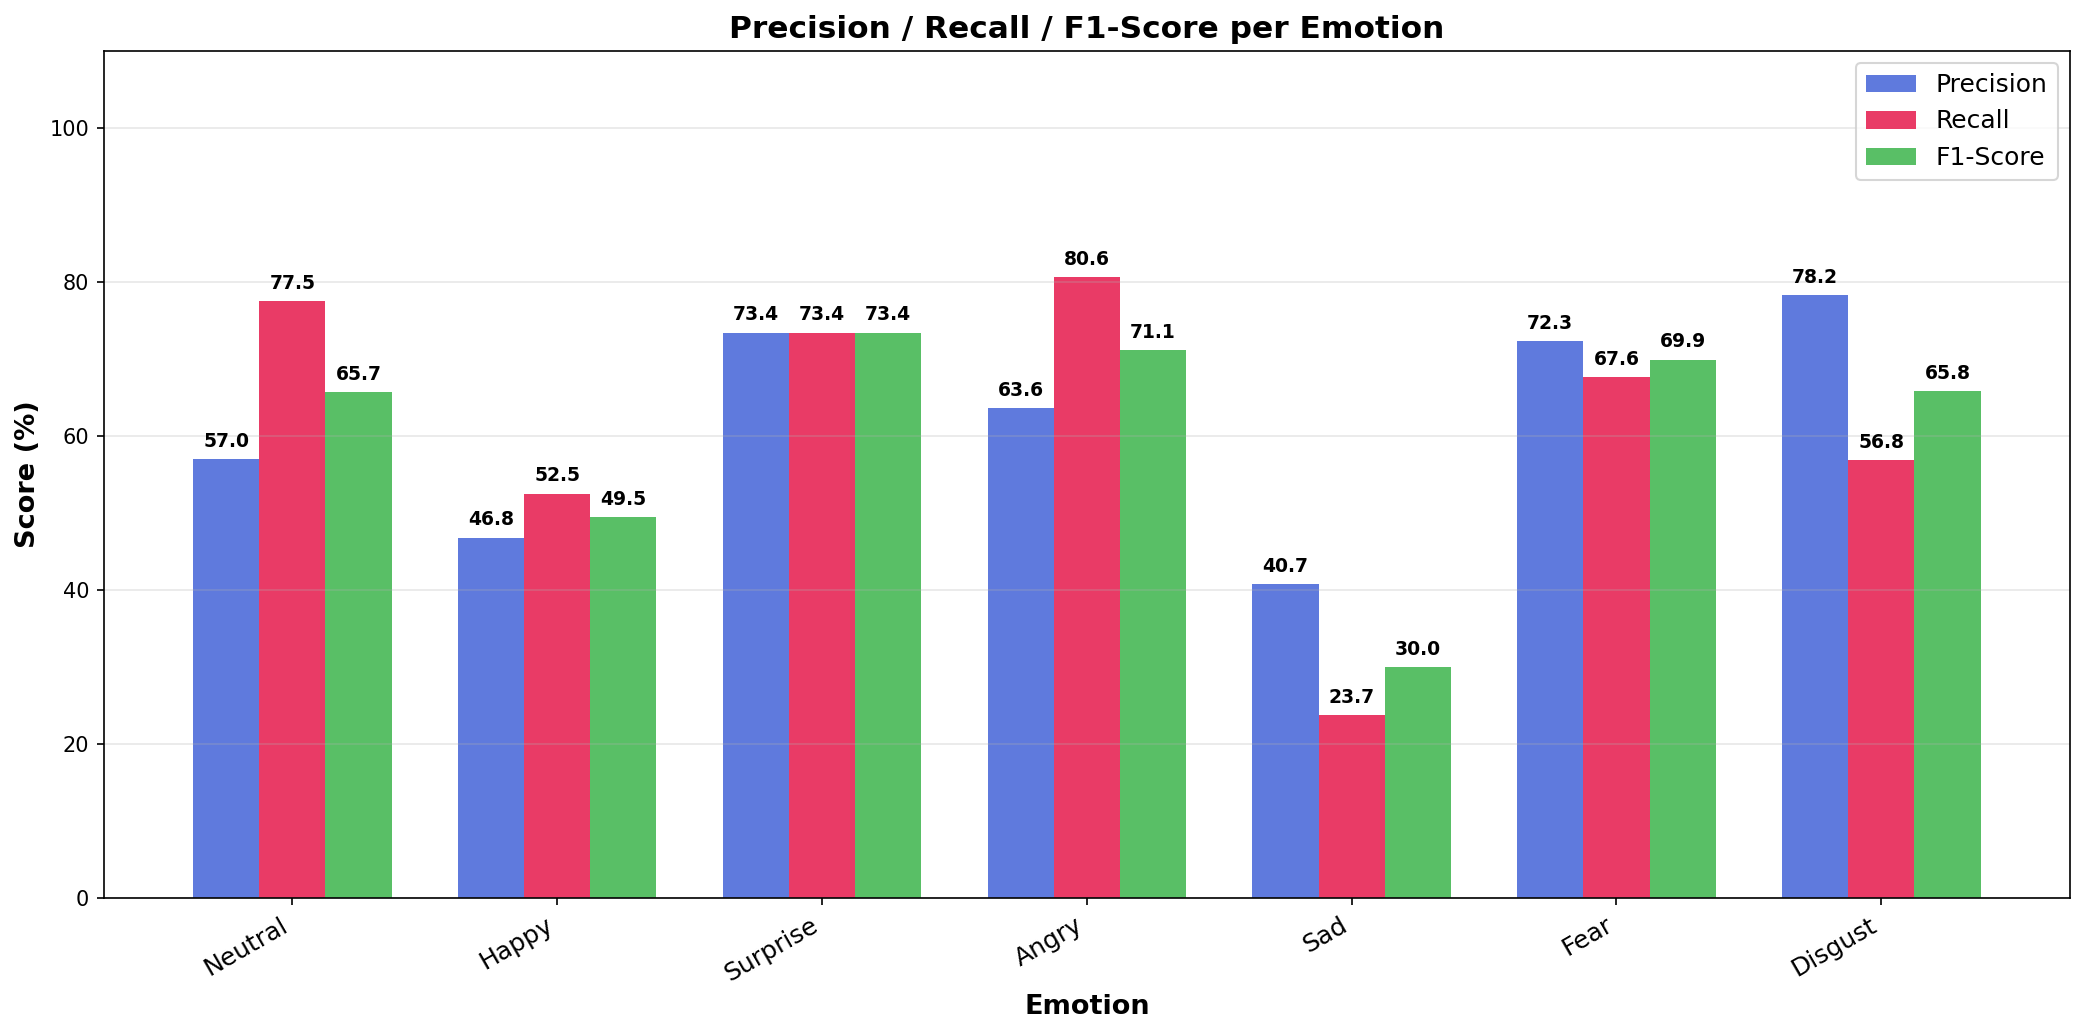

Da luu: precision_recall_f1_bar.png


In [19]:
# ==========================================
# BAR CHART: PRECISION / RECALL / F1 PER CLASS
# ==========================================
precisions = [report_dict[name]['precision'] * 100 for name in present_label_names]
recalls = [report_dict[name]['recall'] * 100 for name in present_label_names]
f1s = [report_dict[name]['f1-score'] * 100 for name in present_label_names]

x_pos = np.arange(num_classes)
bar_width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))

bars1 = ax.bar(x_pos - bar_width, precisions, bar_width, label='Precision', color='#4363d8', alpha=0.85)
bars2 = ax.bar(x_pos, recalls, bar_width, label='Recall', color='#e6194b', alpha=0.85)
bars3 = ax.bar(x_pos + bar_width, f1s, bar_width, label='F1-Score', color='#3cb44b', alpha=0.85)

# Hien thi gia tri tren cot
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Emotion', fontsize=13, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=13, fontweight='bold')
ax.set_title('Precision / Recall / F1-Score per Emotion', fontsize=15, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(present_label_names, fontsize=12, rotation=30, ha='right')
ax.set_ylim(0, 110)
ax.legend(fontsize=12, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('precision_recall_f1_bar.png', bbox_inches='tight', dpi=200)
plt.show()
print("Da luu: precision_recall_f1_bar.png")

In [20]:
# ==========================================
# TONG HOP TAT CA METRICS
# ==========================================
overall_acc = accuracy_score(all_labels, all_preds) * 100
macro_precision = precision_score(all_labels, all_preds, labels=unique_labels, average='macro', zero_division=0) * 100
macro_recall = recall_score(all_labels, all_preds, labels=unique_labels, average='macro', zero_division=0) * 100
macro_f1 = f1_score(all_labels, all_preds, labels=unique_labels, average='macro', zero_division=0) * 100
weighted_f1 = f1_score(all_labels, all_preds, labels=unique_labels, average='weighted', zero_division=0) * 100

print("=" * 55)
print("        TONG HOP KET QUA DANH GIA MODEL")
print("=" * 55)
print(f"   Overall Accuracy  : {overall_acc:.2f}%")
print(f"   Macro Precision   : {macro_precision:.2f}%")
print(f"   Macro Recall      : {macro_recall:.2f}%")
print(f"   Macro F1-Score    : {macro_f1:.2f}%")
print(f"   Weighted F1-Score : {weighted_f1:.2f}%")
print(f"   Macro AUC (OvR)   : {roc_auc['macro']:.4f}")
print(f"   Micro AUC (OvR)   : {roc_auc['micro']:.4f}")
print("=" * 55)

# Luu ket qua ra file
summary = {
    'Metric': ['Overall Accuracy', 'Macro Precision', 'Macro Recall',
               'Macro F1', 'Weighted F1', 'Macro AUC', 'Micro AUC'],
    'Value': [f'{overall_acc:.2f}%', f'{macro_precision:.2f}%', f'{macro_recall:.2f}%',
              f'{macro_f1:.2f}%', f'{weighted_f1:.2f}%', f'{roc_auc["macro"]:.4f}', f'{roc_auc["micro"]:.4f}']
}
pd.DataFrame(summary).to_csv('evaluation_summary.csv', index=False)
print("\nDa luu: evaluation_summary.csv")

print("\nDanh sach file bieu do da tao:")
for f in ['train_val_curves.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png',
          'roc_curve_multiclass.png', 'roc_curve_per_class.png', 'precision_recall_f1_bar.png']:
    status = "OK" if os.path.exists(f) else "MISSING"
    print(f"   [{status}] {f}")

        TONG HOP KET QUA DANH GIA MODEL
   Overall Accuracy  : 61.78%
   Macro Precision   : 61.72%
   Macro Recall      : 61.73%
   Macro F1-Score    : 60.77%
   Weighted F1-Score : 60.78%
   Macro AUC (OvR)   : 0.9074
   Micro AUC (OvR)   : 0.8919

Da luu: evaluation_summary.csv

Danh sach file bieu do da tao:
   [OK] train_val_curves.png
   [OK] confusion_matrix.png
   [OK] confusion_matrix_normalized.png
   [OK] roc_curve_multiclass.png
   [OK] roc_curve_per_class.png
   [OK] precision_recall_f1_bar.png


In [21]:
# === DEBUG CODE ===
print("1. Phan phoi trong CSV:")
print(test_df_custom['emotion'].value_counts())

print("\n2. Unique values (raw):")
print(test_df_custom['emotion'].unique())

print("\n3. Kiem tra all_labels sau inference:")
from collections import Counter
print(Counter(all_labels.tolist()))

print("\n4. Kiem tra all_preds sau inference:")
print(Counter(all_preds.tolist()))

print("\n5. Kiem tra SERDataset label_map:")
if hasattr(test_dataset_custom, 'label_map'):
    print(test_dataset_custom.label_map)
else:
    print("Khong tim thay attribute label_map")

1. Phan phoi trong CSV:
emotion
neutral     142
happy       139
sad         139
angry       139
fear        139
disgust     139
surprise    139
Name: count, dtype: int64

2. Unique values (raw):
['neutral' 'happy' 'sad' 'angry' 'fear' 'disgust' 'surprise']

3. Kiem tra all_labels sau inference:
Counter({0: 142, 1: 139, 4: 139, 3: 139, 5: 139, 6: 139, 2: 139})

4. Kiem tra all_preds sau inference:
Counter({0: 193, 3: 176, 1: 156, 2: 139, 5: 130, 6: 101, 4: 81})

5. Kiem tra SERDataset label_map:
{'neutral': 0, 'happy': 1, 'surprise': 2, 'angry': 3, 'sad': 4, 'fear': 5, 'disgust': 6}
